# Householder methods #

This Jupyter notebook contains commands to explore the effectiveness of Householder iterative methods 
\begin{equation}
x_{n+1} = x_n + k \frac{ (1/f)^{(k-1)}(x_k)}{(1/f)^{(k)}(x_k)}
\end{equation}
for solving the equation $f(x) = 0$ starting from an initial approximation $x_0$.

© Robert M. Corless 2026 (MIT Release licence)

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.


In [1]:
asympt( Wrightomega(x), x, 4 );

kilobytes used=744, alloc=5168, time=0.17

$$x -\ln \left(x \right)+\frac{\ln \left(x \right)}{x}+\frac{-\ln \left(x \right)+\frac{\ln \left(x \right)^{2}}{2}}{x^{2}}+\frac{\ln \left(x \right)-\frac{3 \ln \left(x \right)^{2}}{2}+\frac{\ln \left(x \right)^{3}}{3}}{x^{3}}+O\left(\frac{1}{x^{4}}\right)$$

In [2]:
f := w + ln(w)-x;

$$w +\ln \left(w \right)-x$$

In [3]:
diff(1/f, w);

$$-\frac{1+\frac{1}{w}}{\left(w +\ln \left(w \right)-x \right)^{2}}$$

In [4]:
N := 5:
ders := Array(0..N ):
ders[0] := 1/f:
for k to N do
  ders[k] := diff(ders[k-1],w);
end do:

In [5]:
normal(ders[N]);

$$-\frac{2 \left(60-120 x +420 w -234 \ln \left(w \right)^{2} w x -444 \ln \left(w \right) w^{2} x +234 \ln \left(w \right) w \,x^{2}-630 \ln \left(w \right) w x +12 \ln \left(w \right)^{4}+50 \ln \left(w \right)^{3}+105 \ln \left(w \right)^{2}+60 w^{5}+522 w^{4}+12 x^{4}+1175 w^{3}-50 x^{3}+78 \ln \left(w \right)^{3} w -48 \ln \left(w \right)^{3} x +222 \ln \left(w \right)^{2} w^{2}+72 \ln \left(w \right)^{2} x^{2}+378 \ln \left(w \right) w^{3}-48 \ln \left(w \right) x^{3}+315 \ln \left(w \right)^{2} w -150 \ln \left(w \right)^{2} x +840 \ln \left(w \right) w^{2}+150 \ln \left(w \right) x^{2}+570 w \ln \left(w \right)-210 \ln \left(w \right) x +1065 w^{2}-570 w x +105 x^{2}-378 w^{3} x +222 w^{2} x^{2}-78 w \,x^{3}-840 w^{2} x +315 w \,x^{2}+120 \ln \left(w \right)\right)}{\left(w +\ln \left(w \right)-x \right)^{6} w^{5}}$$

In [6]:
H := Array(1..N):
for k to N do
  H[k] := unapply( w + k*factor(ders[k-1]/ders[k]), w );
end do:

In [7]:
codegen[cost]( [codegen[optimize](H[1](w), tryhard)] );

$$\mathit{multiplications} +4 \mathit{additions} +\mathit{functions} +\mathit{divisions} +\mathit{assignments}$$

In [8]:
codegen[cost]( [codegen[optimize](H[2](w), tryhard)] );

$$\mathit{functions} +7 \mathit{additions} +2 \mathit{assignments} +5 \mathit{multiplications} +\mathit{divisions}$$

In [9]:
codegen[cost]( [codegen[optimize](H[3](w), tryhard)] );

$$15 \mathit{additions} +13 \mathit{multiplications} +5 \mathit{assignments} +\mathit{functions} +\mathit{divisions}$$

In [10]:
codegen[cost]( [codegen[optimize](H[4](w), tryhard)] );

kilobytes used=7835, alloc=18601, time=0.87

$$31 \mathit{additions} +32 \mathit{multiplications} +9 \mathit{assignments} +\mathit{functions} +\mathit{divisions}$$

In [11]:
codegen[cost]( [codegen[optimize](H[5](w), tryhard)] );

$$55 \mathit{additions} +62 \mathit{multiplications} +12 \mathit{assignments} +\mathit{functions} +\mathit{divisions}$$

In [12]:
H[2](w);

$$w -\frac{2 w \left(w +\ln \left(w \right)-x \right) \left(w +1\right)}{2 w^{2}+\ln \left(w \right)+5 w -x +2}$$

In [13]:
res2 := H[2](w) + ln(H[2](w)) - x;

$$w -\frac{2 w \left(w +\ln \left(w \right)-x \right) \left(w +1\right)}{2 w^{2}+\ln \left(w \right)+5 w -x +2}+\ln \left(w -\frac{2 w \left(w +\ln \left(w \right)-x \right) \left(w +1\right)}{2 w^{2}+\ln \left(w \right)+5 w -x +2}\right)-x$$

The backward error of H[2] is proportional to $r^3$: that is, if the error in the approximation $w_k$ is about $r$, then the error in $w_{k+1}$ will be $O(r^3)$.

In [14]:
resr := eval( res2, x=w+ln(w)-r ):
map( simplify, series( resr, r, 5 ));

$$\frac{-4 w -1}{12 \left(w +1\right)^{4}} r^{3}-\frac{1}{4} \frac{w^{2}}{\left(w +1\right)^{6}} r^{4}+\mathrm{O}\left(r^{5}\right)$$

In [15]:
res3 := H[3](w) + ln(H[3](w)) - x;

$$w -\frac{3 w \left(w +\ln \left(w \right)-x \right) \left(2 w^{2}+\ln \left(w \right)+5 w -x +2\right)}{2 \left(3 w^{3}+\ln \left(w \right)^{2}+5 w \ln \left(w \right)-2 \ln \left(w \right) x +13 w^{2}-5 w x +x^{2}+3 \ln \left(w \right)+12 w -3 x +3\right)}+\ln \left(w -\frac{3 w \left(w +\ln \left(w \right)-x \right) \left(2 w^{2}+\ln \left(w \right)+5 w -x +2\right)}{2 \left(3 w^{3}+\ln \left(w \right)^{2}+5 w \ln \left(w \right)-2 \ln \left(w \right) x +13 w^{2}-5 w x +x^{2}+3 \ln \left(w \right)+12 w -3 x +3\right)}\right)-x$$

The backward error of H[3] is proportional to $r^4$; that is, if the error in the approximation $w_k$ is about $r$, then the error in $w_{k+1}$ will be $O(r^4)$.

In [16]:
resr := eval( res3, x=w+ln(w)-r ):

In [17]:
theor := map( simplify, series( resr, r, 6 ) );

$$\frac{-6 w^{2}-4 w -1}{24 \left(w +1\right)^{6}} r^{4}+\frac{1}{180} \frac{-36 w^{3}+22 w^{2}+17 w +4}{\left(w +1\right)^{8}} r^{5}+\mathrm{O}\left(r^{6}\right)$$

In [32]:
latex( coeff(theor,r,4) );

\frac{-6 w^{2}-4 w -1}{24 \left(w +1\right)^{6}}

In [18]:
Digits := 2000:
x := rand()/Float(1,12):
wref := Wrightomega(x):
N := 5:
wt := Array(0..N):
err := Array(0..N):
rat := Array(1..N):
wt[0] := 0.5:
err[0] := wt[0]-wref:
for k to N do
  wt[k] := H[3](wt[k-1]):
  err[k] := wt[k] + ln(wt[k]) - x :
  rat[k] := err[k]/err[k-1]^4:
end do:

In [19]:
[seq( evalf[5]( err[k] ), k=0..N )];

| | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|
|-.42499|-.23824e-1|-.26441e-8|-.39360e-36|-.19326e-147|-.11232e-592|


In [20]:
[seq( evalf[5]( rat[k] ), k=1..N )];

| | | | | |
|:-:|:-:|:-:|:-:|:-:|
|-.73031|-.82072e-2|-.80525e-2|-.80525e-2|-.80525e-2|


In [21]:
Digits := 15:
eval( theor, w=wref );

$$\left(- 0.00805248672047508\right) r^{4}+ 0.000296317325651154 r^{5}+\mathrm{O}\left(r^{6}\right)$$

In [22]:
x := 'x':
Digits := 15:

Now explore what happens when we use a simple initial approximation that is good for large $x$.

In [23]:
one := eval(res2, w=x );

$$-\frac{2 x \ln \left(x \right) \left(x +1\right)}{2 x^{2}+\ln \left(x \right)+4 x +2}+\ln \left(x -\frac{2 x \ln \left(x \right) \left(x +1\right)}{2 x^{2}+\ln \left(x \right)+4 x +2}\right)$$

In [24]:
two := eval(res2, w=x-ln(x));

$$-\ln \left(x \right)-\frac{2 \left(x -\ln \left(x \right)\right) \left(-\ln \left(x \right)+\ln \left(x -\ln \left(x \right)\right)\right) \left(x -\ln \left(x \right)+1\right)}{2 \left(x -\ln \left(x \right)\right)^{2}+\ln \left(x -\ln \left(x \right)\right)+4 x -5 \ln \left(x \right)+2}+\ln \left(x -\ln \left(x \right)-\frac{2 \left(x -\ln \left(x \right)\right) \left(-\ln \left(x \right)+\ln \left(x -\ln \left(x \right)\right)\right) \left(x -\ln \left(x \right)+1\right)}{2 \left(x -\ln \left(x \right)\right)^{2}+\ln \left(x -\ln \left(x \right)\right)+4 x -5 \ln \left(x \right)+2}\right)$$

In [25]:
three := eval( res2, w=x-ln(x)+ln(x)/x );

$$-\ln \left(x \right)+\frac{\ln \left(x \right)}{x}-\frac{2 \left(x -\ln \left(x \right)+\frac{\ln \left(x \right)}{x}\right) \left(-\ln \left(x \right)+\frac{\ln \left(x \right)}{x}+\ln \left(x -\ln \left(x \right)+\frac{\ln \left(x \right)}{x}\right)\right) \left(x -\ln \left(x \right)+\frac{\ln \left(x \right)}{x}+1\right)}{2 \left(x -\ln \left(x \right)+\frac{\ln \left(x \right)}{x}\right)^{2}+\ln \left(x -\ln \left(x \right)+\frac{\ln \left(x \right)}{x}\right)+4 x -5 \ln \left(x \right)+\frac{5 \ln \left(x \right)}{x}+2}+\ln \left(x -\ln \left(x \right)+\frac{\ln \left(x \right)}{x}-\frac{2 \left(x -\ln \left(x \right)+\frac{\ln \left(x \right)}{x}\right) \left(-\ln \left(x \right)+\frac{\ln \left(x \right)}{x}+\ln \left(x -\ln \left(x \right)+\frac{\ln \left(x \right)}{x}\right)\right) \left(x -\ln \left(x \right)+\frac{\ln \left(x \right)}{x}+1\right)}{2 \left(x -\ln \left(x \right)+\frac{\ln \left(x \right)}{x}\right)^{2}+\ln \left(x -\ln \left(x \right)+\frac{\ln \left(x \right)}{x}\right)+4 x -5 \ln \left(x \right)+\frac{5 \ln \left(x \right)}{x}+2}\right)$$

In [26]:
npts := 1001:
hex := Vector( npts, datatype=float[8], i -> 1 + (i-1)*101/(npts-1)):

In [27]:
redwhy := Vector( npts, datatype=float[8] ):
greenwhy := Vector( npts, datatype=float[8] ):
bluewhy := Vector( npts, datatype=float[8] ):

In [28]:
for i to npts do
  redwhy[i] := evalf( eval(one, x=hex[i] ) ):
  greenwhy[i] := evalf( eval(two, x=hex[i] ) ) :
  bluewhy[i] := evalf( eval(three, x=hex[i] ) ):
end do:

In [29]:
reddat := [seq( [hex[i], log[10](abs( redwhy[i] ) )], i=1..npts )]:
greendat := [seq( [hex[i], log[10](abs( greenwhy[i] ) )], i=1..npts )]:
bluedat := [seq( [hex[i], log[10](abs( bluewhy[i] ) )], i=1..npts )]:

In [30]:
redplot := plots[pointplot]( reddat, style=point, symbol=point, colour=red ):
greenplot := plots[pointplot]( greendat, style=point, symbol=point, colour=green ):
blueplot := plots[pointplot]( bluedat, style=point, symbol=point, colour=blue ):

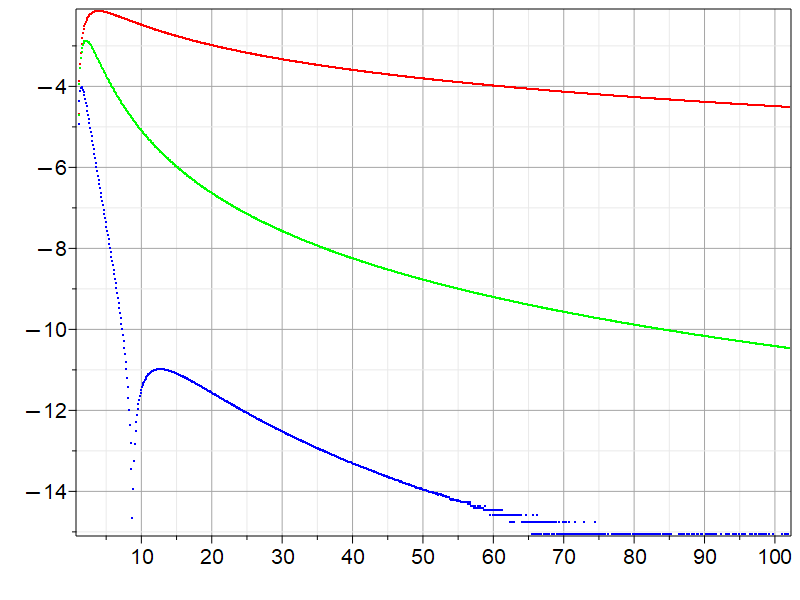

In [31]:
plots[display]( [redplot, greenplot, blueplot], gridlines);

We see that the residuals one step of each of the three methods get very small as $x$ gets larger.  For $x$ bigger than about $70$, the third-order Householder method essentially gets full double-precision accuracy in one step with the initial approximation $x - \ln x + \ln x/x$.